In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")

## Task 1: Build and Summarize Synthetic Datasets

In [2]:
data_a=np.random.normal(loc=50, scale=10, size=500)
data_b=np.random.exponential(scale=15, size=500)
data_b=(data_b/data_b.max())*100
data_c1=np.random.normal(loc=30, scale=8, size=250)
data_c2=np.random.normal(loc=70, scale=8, size=250)
data_c=np.concatenate([data_c1,data_c2])
def get_stats(data):
    return {
        "Mean": np.round(np.mean(data), 2),
        "Median": np.round(np.median(data), 2),
        "Mode": np.round(stats.mode(data, keepdims=True)[0][0], 2),
        "Standard deviation": np.round(np.std(data), 2),
        "Variance": np.round(np.var(data), 2),
        "IQR": np.round(stats.iqr(data), 2),
        "Skewness": np.round(stats.skew(data), 2),
        "Kurtosis": np.round(stats.kurtosis(data), 2)
    }
summary=pd.DataFrame({
    "Dataset A (Symmetric) ": get_stats(data_a),
    "Dataset B (Right-Skewed)": get_stats(data_b),
    "Dataset C (Bimodal)": get_stats(data_c)
})

print(f"Summary: {summary}")

Summary:                     Dataset A (Symmetric)   Dataset B (Right-Skewed)  \
Mean                                 50.07                     16.23   
Median                               50.13                     11.35   
Mode                                 17.59                      0.08   
Standard deviation                    9.80                     15.96   
Variance                             96.09                    254.75   
IQR                                  13.37                     18.64   
Skewness                              0.18                      1.77   
Kurtosis                              0.26                      3.98   

                    Dataset C (Bimodal)  
Mean                              50.52  
Median                            49.25  
Mode                               6.83  
Standard deviation                21.02  
Variance                         441.75  
IQR                               38.42  
Skewness                           0.02  
Kurtos

 Dataset A (Symmetric) and Dataset C (Bimodal) look similar. but Dataset B (Right-Skewed) reveal the difference.

## Task 2: Visualize the Distributions

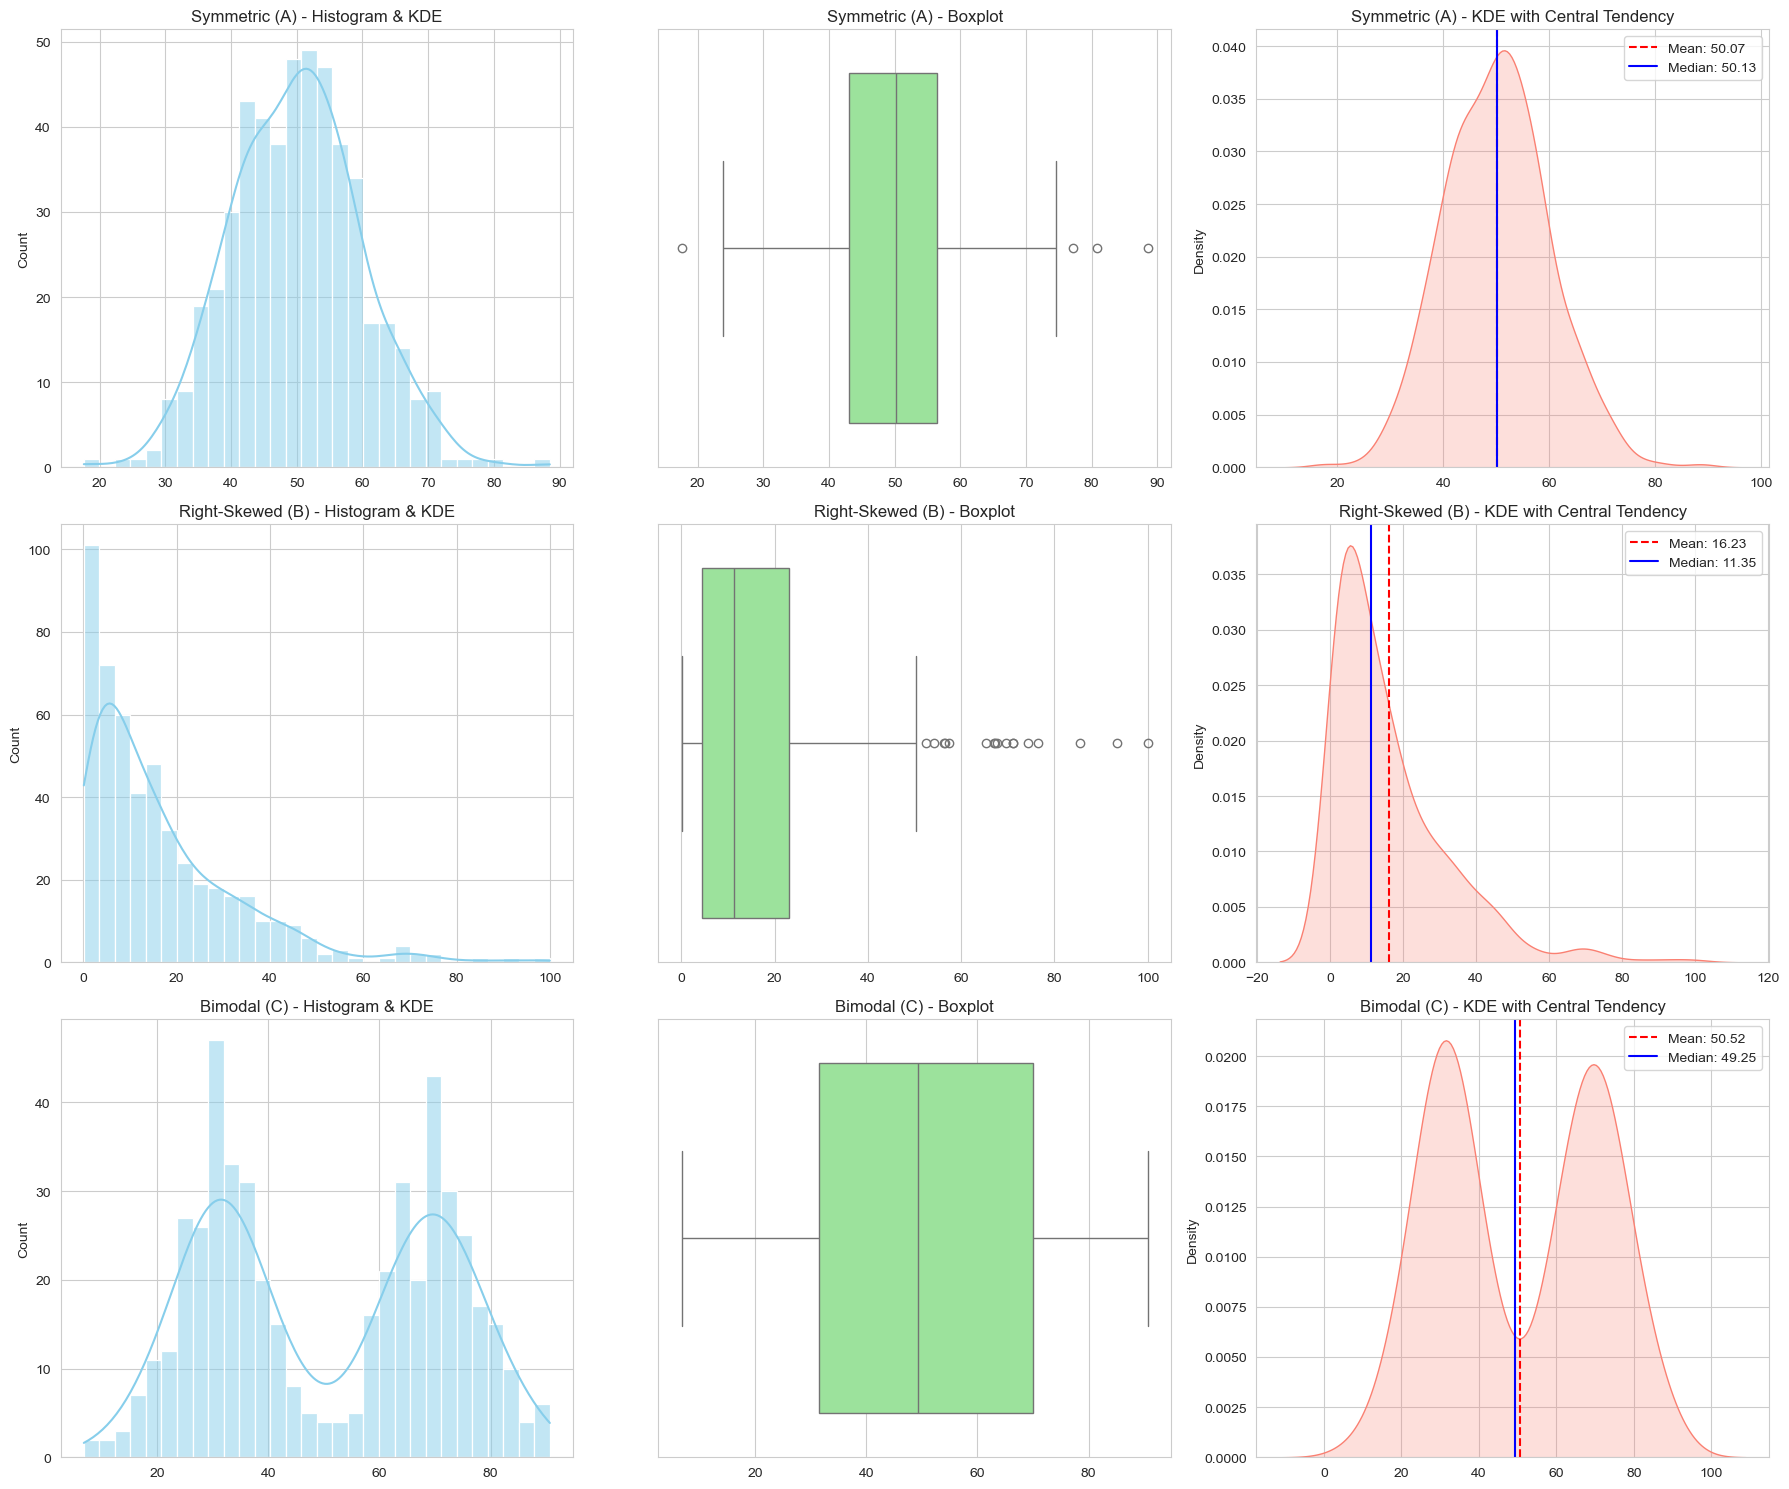

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
datasets = [("Symmetric (A)", data_a), ("Right-Skewed (B)", data_b), ("Bimodal (C)", data_c)]

for i, (name, data) in enumerate(datasets):
    sns.histplot(data, bins=30, kde=True, ax=axes[i, 0], color="skyblue")
    axes[i, 0].set_title(f"{name} - Histogram & KDE")
    sns.boxplot(x=data, ax=axes[i, 1], color="lightgreen")
    axes[i, 1].set_title(f"{name} - Boxplot")
    sns.kdeplot(data, ax=axes[i, 2], fill=True, color="salmon")
    mean_val = np.mean(data)
    median_val = np.median(data)
    axes[i, 2].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i, 2].axvline(median_val, color='blue', linestyle='-', label=f'Median: {median_val:.2f}')
    axes[i, 2].set_title(f"{name} - KDE with Central Tendency")
    axes[i, 2].legend()

plt.tight_layout()
plt.show()

The mean and median diverge the most in Dataset B (Right-Skewed). In this distribution, the mean is significantly higher than the median. The primary visual feature that explains the divergence is the long right tail (positive skewness).

## Task 3: The Outlier Stress Test

                    Original Dataset A  Modified (with Outliers)
Mean                             50.07                     57.17
Median                           50.13                     50.13
Mode                             17.59                     17.59
Standard deviation                9.80                     74.31
Variance                         96.09                   5521.42
IQR                              13.37                     13.37
Skewness                          0.18                      9.70
Kurtosis                          0.26                     94.18


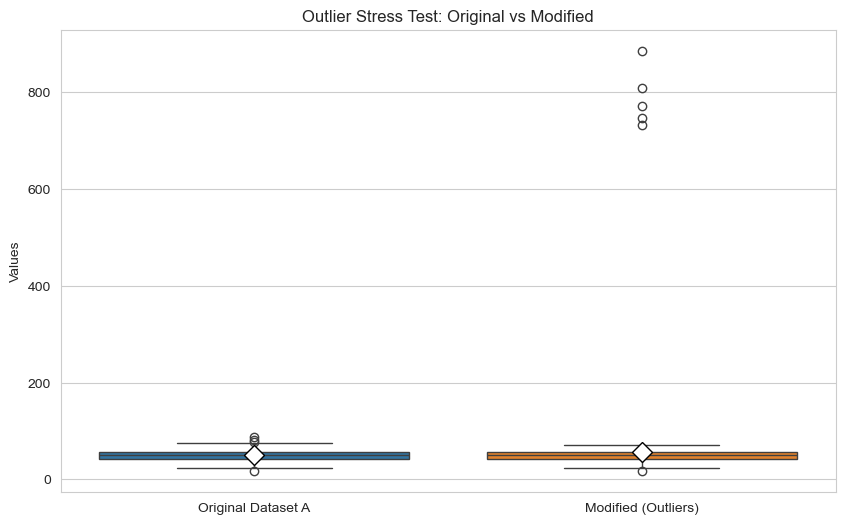

In [4]:
data_modified=data_a.copy()
largest_indices = np.argsort(data_modified)[-5:]
data_modified[largest_indices] = data_modified[largest_indices] * 10
outlier_test_df = pd.DataFrame({
    "Original Dataset A": get_stats(data_a),
    "Modified (with Outliers)": get_stats(data_modified)
})
print(outlier_test_df)
plt.figure(figsize=(10, 6))
sns.boxplot(data=[data_a, data_modified], 
            showmeans=True, 
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})

plt.xticks([0, 1], ["Original Dataset A", "Modified (Outliers)"])
plt.title("Outlier Stress Test: Original vs Modified")
plt.ylabel("Values")
plt.show()

- The Mean, Standard Deviation, and Kurtosis changed the most due to their sensitivity to extreme values, while the Median, Mode, and IQR remained robust and virtually unchanged.
- I would choose the Median because it accurately represents the center of the majority of the data, whereas the Mean is pulled away by the five extreme outliers and no longer reflects a "typical" observation.